In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation

from model import Variables
from hcv_surgery import HC_VALLEY_BATTERY_REDUCED_MOD as DATA, surgery

def rec_map(f, a):
    if isinstance(a, (list, tuple)):
        return [rec_map(f, x) for x in a]
    if isinstance(a, dict):
        return {k: rec_map(f, x) for k, x in a.items()}
    else:
        return f(a)

In [2]:
def plot(
    varibs: Variables,
    makeup: bool = True,
    ax: plt.Axes | None = None,
    xmax: int | None = None,
    ymax: int | None = None,
    existing: dict | None = None,
):
    xmax = xmax or max(
        max(max(arr) for arr in varibs.conveyor_segment_end_x) + 1,
        max(
            a + b
            for a, b in zip(varibs.building_x.values(), varibs.building_dx.values())
        ),
    )
    ymax = ymax or max(
        max(max(arr) for arr in varibs.conveyor_segment_end_y) + 1,
        max(
            a + b
            for a, b in zip(varibs.building_y.values(), varibs.building_dy.values())
        ),
    )

    ret_fig = False
    if ax is None:
        ret_fig = True
        fig, ax = plt.subplots(figsize=(int(xmax / ymax * 10), 10))

    colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "gray"]
    orientations = ["NORTH", "SOUTH", "EAST", "WEST"]

    elements = {"patch": [], "text": [], "conveyor": []}

    # Buildings
    for i, building in enumerate(DATA.buildings):
        x, y, w, h, o = (
            varibs.building_x[building.name],
            varibs.building_y[building.name],
            varibs.building_dx[building.name],
            varibs.building_dy[building.name],
            varibs.building_orientation[building.name],
        )
        o = orientations[o]
        if existing is None:
            rect = patches.Rectangle(
                (x, y),
                w,
                h,
                linewidth=1,
                edgecolor="black",
                facecolor="lightblue",
                alpha=0.7,
            )
            ax.add_patch(rect)
            text = ax.text(
                x + w / 2,
                y + h / 2,
                f"{building.name} ({o[0]})",
                ha="center",
                va="center",
                fontsize=8,
                weight="bold",
            )
            elements["patch"].append(rect)
            elements["text"].append(text)
        else:
            existing["patch"][i].set_width(w)
            existing["patch"][i].set_height(h)
            existing["patch"][i].set_xy((x, y))
            existing["text"][i].set_position((x + w / 2, y + h / 2))
            existing["text"][i].set_text(f"{building.name} ({o[0]})")

    # Conveyors
    for c, ((b1, b2), start_x, start_y, seg_end_x, seg_end_y) in enumerate(
        zip(
            DATA.conveyor_joins,
            varibs.conveyor_start_x,
            varibs.conveyor_start_y,
            varibs.conveyor_segment_end_x,
            varibs.conveyor_segment_end_y,
        )
    ):
        elements["conveyor"].append(draw := [])

        if b1 is None:
            b1_ori = orientations[DATA.pickups[varibs.pickup_perm[c]].orientation]
        else:
            b1_ori = orientations[varibs.building_orientation[b1]]
        dx = {"EAST": -0.5, "WEST": 0.5}.get(b1_ori, 0)
        dy = {"NORTH": -0.5, "SOUTH": 0.5}.get(b1_ori, 0)
        x, y = start_x + 0.5, start_y + 0.5
        if existing is None:
            lines = ax.plot(
                [x, x + dx], [y, y + dy], colors[c % len(colors)], linewidth=2
            )
            assert len(lines) == 1
            draw.append(lines[0])
        else:
            line, _, _ = existing["conveyor"][c]
            line.set_data([x, x + dx], [y, y + dy])

        b2_ori = orientations[varibs.building_orientation[b2]]
        dx = {"EAST": 0.5, "WEST": -0.5}.get(b2_ori, 0)
        dy = {"NORTH": 0.5, "SOUTH": -0.5}.get(b2_ori, 0)
        x, y = seg_end_x[-1] + 0.5, seg_end_y[-1] + 0.5
        if existing is None:
            draw.append(
                ax.quiver(
                    x,
                    y,
                    dx,
                    dy,
                    angles="xy",
                    scale_units="xy",
                    scale=1,
                    color=colors[c % len(colors)],
                    width=0.003,
                )
            )
        else:
            _, quiver, _ = existing["conveyor"][c]
            quiver.set_offsets([x, y])
            quiver.set_UVC(dx, dy)

        segs = []
        for i, (x1, x2, y1, y2) in enumerate(
            zip([start_x] + seg_end_x, seg_end_x, [start_y] + seg_end_y, seg_end_y)
        ):
            if existing is None:
                segs.extend(
                    lines := ax.plot(
                        [x1 + 0.5, x2 + 0.5],
                        [y1 + 0.5, y2 + 0.5],
                        colors[c % len(colors)],
                        linewidth=2,
                    )
                )
                assert len(lines) == 1
            else:
                _, _, lines = existing["conveyor"][c]
                lines[i].set_data([x1 + 0.5, x2 + 0.5], [y1 + 0.5, y2 + 0.5])
        draw.append(segs)

    if makeup:
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_title("Endfield Design")
        ax.set_xlim(0, xmax)
        ax.set_ylim(0, ymax)

        x_ticks = [i + 0.5 for i in range(xmax)]
        x_labels = [i for i in range(xmax)]
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels)
        y_ticks = [i + 0.5 for i in range(ymax)]
        y_labels = [i for i in range(ymax)]
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labels)
        # Grid at integers
        ax.vlines(range(xmax + 1), 0, ymax, alpha=0.3, color="gray", linewidth=0.5)
        ax.hlines(range(ymax + 1), 0, xmax, alpha=0.3, color="gray", linewidth=0.5)

    rec_map(lambda artist: artist.set_animated(True), elements)
    if ret_fig:
        return fig
    return elements

In [3]:
with open("runs/log_reduced8.txt") as f:
    varibs = [line for line in f.readlines() if line.startswith("Variables")]

varibs = [surgery(eval(v)) for v in varibs]

In [4]:
def compute_bounds(varibs: Variables) -> tuple[int, int]:
    xmax = max(
        max(max(arr) for arr in varibs.conveyor_segment_end_x) + 1,
        max(
            a + b
            for a, b in zip(varibs.building_x.values(), varibs.building_dx.values())
        ),
    )
    ymax = max(
        max(max(arr) for arr in varibs.conveyor_segment_end_y) + 1,
        max(
            a + b
            for a, b in zip(varibs.building_y.values(), varibs.building_dy.values())
        ),
    )
    return xmax, ymax

In [5]:
XMAX, YMAX = [*map(max, zip(*[compute_bounds(v) for v in varibs]))]
XMAX, YMAX

(28, 30)

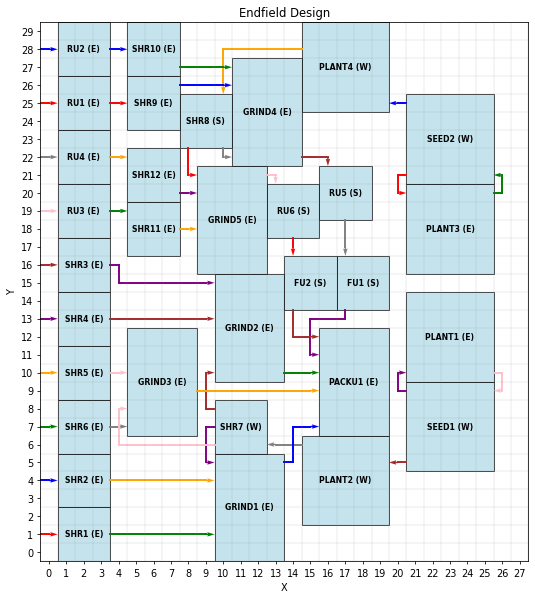

In [6]:
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(int(XMAX / YMAX * 10), 10), dpi=70)
ax.set_xlim(0, XMAX)
ax.set_ylim(0, YMAX)

elems = plot(varibs[0], makeup=True, ax=ax, xmax=XMAX, ymax=YMAX)

def flatten(a):
    res = []
    rec_map(res.append, a)
    return res

def init_func():
    return flatten(elems)

def update(frame):
    plot(varibs[frame], makeup=False, ax=ax, xmax=XMAX, ymax=YMAX, existing=elems)
    return flatten(elems)

ani = FuncAnimation(fig, update, frames=len(varibs), blit=True)

ani_jshtml = ani.to_jshtml()
HTML(ani_jshtml)

In [7]:
with open("out.html", "w") as f:
    f.write(ani_jshtml)

In [8]:
from tqdm import tqdm

for i, v in enumerate(tqdm(varibs)):
    fig = plot(v, makeup=True, xmax=XMAX, ymax=YMAX)
    fig.savefig(f"figs/{i}.png", dpi=70)
    plt.close(fig)

100%|██████████| 29/29 [00:09<00:00,  3.15it/s]


In [9]:
offset = 0
offsets = [offset]
imgs = []
for i, _ in enumerate(varibs):
    with open(f"figs/{i}.png", "rb") as f:
        data = f.read()
        imgs.append(data)
        offset += len(data)
        offsets.append(offset)

offsets

[0,
 54392,
 108472,
 162520,
 216503,
 270545,
 324569,
 378529,
 432239,
 486649,
 540721,
 594708,
 648347,
 701967,
 755534,
 809082,
 862591,
 915842,
 969432,
 1022707,
 1076069,
 1128927,
 1181592,
 1234245,
 1286997,
 1339752,
 1392484,
 1445166,
 1497476,
 1550014]

In [ ]:
with open("figs/combined.dat", "wb") as f:
    f.write(b"".join(imgs))